<a href="https://colab.research.google.com/github/vansh7nvc/NeuroGAN/blob/main/RAW_MRI_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeuroGAN – Phase 1: Baseline & Data Diagnosis

In [ ]:
#setup

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
#reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using deviceL", device)

Using deviceL cuda


In [ ]:
import pandas as pd
import numpy as np
import os
# For loading images, we'll use a standard library like PIL (Pillow)
from PIL import Image

In [ ]:
# Files: train.parquet and test.parquet

# Load the training set
try:
    train_df = pd.read_parquet('/train.parquet')
    print("train.parquet loaded into a DataFrame.")
    print(train_df.head())
except FileNotFoundError:
    print("Error: train.parquet not found. Check your file path.")

# Load the test set
try:
    test_df = pd.read_parquet('/test.parquet')
    print("test.parquet loaded into a DataFrame.")
    print(test_df.head())
except FileNotFoundError:
    print("Error: test.parquet not found. Check your file path.")

train.parquet loaded into a DataFrame.
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
test.parquet loaded into a DataFrame.
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0


In [ ]:
train_path = "/train.parquet"
test_path = "/test.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
train_df.head()

Train shape: (5120, 2)
Test shape: (1280, 2)

Train columns: ['image', 'label']


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2


In [ ]:
label_col = "label"
image_col = "image"

Class distribution (Train only)

label
2    2566
3    1781
0     724
1      49
Name: count, dtype: int64


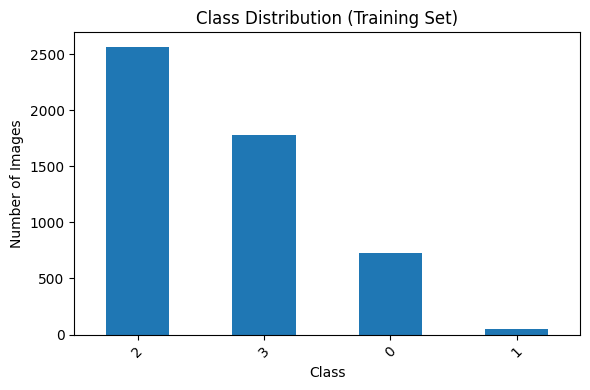

In [ ]:
class_counts = train_df[label_col].value_counts()
print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Label Encoding

In [ ]:
from ctypes.util import test
classes = sorted(train_df[label_col].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in enumerate(classes)}

print("Classes:", classes)
print("Class to idx:", class_to_idx)

train_df["label_idx"] = train_df[label_col].map(class_to_idx)
test_df["label_idx"] = test_df[label_col].map(class_to_idx)

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Class to idx: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3}


Custom dataset from dataframe

In [ ]:
# === Phase 1: Custom Dataset from DataFrame ===

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import io
import base64

IMG_SIZE = 128  # for baseline CNN

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ResNet expects 3 channels
    transforms.ToTensor()
])

class MRIDatasetFromDF(Dataset):
    def __init__(self, df, image_col, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _to_img(self, image_data):
        """
        Convert dict with JPEG bytes -> PIL Image.
        Expected format: {"bytes": b"...", "path": "..."}
        """

        # Case 0: dict with raw JPEG bytes
        if isinstance(image_data, dict):
            if "bytes" in image_data:
                img_bytes = image_data["bytes"]
                img = Image.open(io.BytesIO(img_bytes)).convert("L")  # grayscale
                return img
            else:
                raise ValueError(f"Dict found but missing 'bytes' key: {image_data.keys()}")

        # Anything else should NOT appear for your dataset
        raise ValueError(
            f"Unsupported image format: type={type(image_data)}, keys={getattr(image_data, 'keys', None)}"
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_data = row[self.image_col]
        label_idx = int(row[self.label_col])

        img = self._to_img(image_data)

        if self.transform:
            img = self.transform(img)

        return img, label_idx


In [ ]:
train_full_dataset = MRIDatasetFromDF(train_df, image_col, "label_idx", transform=transform)
test_dataset       = MRIDatasetFromDF(test_df,  image_col, "label_idx", transform=transform)

sample_img, sample_label = train_full_dataset[0]
print(sample_img.shape, sample_label)


torch.Size([3, 128, 128]) 2


In [ ]:
# === Phase 1: Train/Val/Test split ===

torch.manual_seed(SEED)

train_size = int(0.8 * len(train_full_dataset))
val_size   = len(train_full_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


Train: 4096, Val: 1024, Test: 1280


In [ ]:
# === Phase 1: Baseline ResNet18 ===

def get_baseline_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

num_classes = len(classes)

model = get_baseline_model(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 5  # baseline only


In [ ]:
# === Phase 1: Training & Validation ===

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "baseline_resnet18_best.pth")

print("Best Val Accuracy:", best_val_acc)


Epoch [1/5] Train Loss: 0.7381 | Train Acc: 0.7043 | Val Loss: 0.4305 | Val Acc: 0.8359
Epoch [2/5] Train Loss: 0.1956 | Train Acc: 0.9316 | Val Loss: 0.3037 | Val Acc: 0.8867
Epoch [3/5] Train Loss: 0.0846 | Train Acc: 0.9722 | Val Loss: 0.3104 | Val Acc: 0.8975
Epoch [4/5] Train Loss: 0.0570 | Train Acc: 0.9812 | Val Loss: 0.3457 | Val Acc: 0.8994
Epoch [5/5] Train Loss: 0.0476 | Train Acc: 0.9839 | Val Loss: 0.2223 | Val Acc: 0.9336
Best Val Accuracy: 0.93359375


In [ ]:
# === Phase 1: Final Test Evaluation ===

best_model = get_baseline_model(num_classes).to(device)
best_model.load_state_dict(torch.load("baseline_resnet18_best.pth", map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(best_model, test_loader, criterion, device)

macro_f1    = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(c) for c in classes]))



Test Loss: 0.2420
Test Accuracy: 0.9289
Macro F1-Score: 0.9322
Weighted F1-Score: 0.9287

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.91       172
           1       1.00      0.93      0.97        15
           2       0.94      0.95      0.95       634
           3       0.89      0.93      0.91       459

    accuracy                           0.93      1280
   macro avg       0.96      0.91      0.93      1280
weighted avg       0.93      0.93      0.93      1280



In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
findings_text = f"""Test Loss: {test_loss:.4f}
Test Accuracy: {test_acc:.4f}
Macro F1-Score: {macro_f1:.4f}
Weighted F1-Score: {weighted_f1:.4f}

Classification Report:
{classification_report(y_true, y_pred, target_names=[str(c) for c in classes])}
"""

with open("analysis_findings.txt", "w") as f:
    f.write(findings_text)

print("Analysis findings saved to analysis_findings.txt")

NameError: name 'test_loss' is not defined